In [ ]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv
Saving drug.csv to drug.csv
Saving iris.csv to iris.csv
Saving letter-recognition.csv to letter-recognition.csv


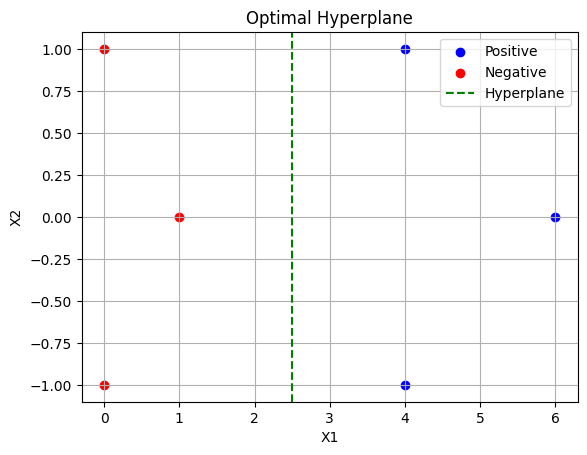

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

pos = np.array([[4,1],[4,-1],[6,0]])
neg = np.array([[1,0],[0,1],[0,-1]])

plt.scatter(pos[:,0], pos[:,1], color='blue', label='Positive')
plt.scatter(neg[:,0], neg[:,1], color='red', label='Negative')

plt.axvline(x=2.5, color='green', linestyle='--', label='Hyperplane')

plt.legend()
plt.title("Optimal Hyperplane")
plt.xlabel("X1")
plt.ylabel("X2")
plt.grid()
plt.show()

In [ ]:
# SVM on iris dataset

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("iris.csv")

X = data.iloc[:, :-1]
y = data.iloc[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

linear_model = SVC(kernel='linear')
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("Linear Kernel Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_linear))

rbf_model = SVC(kernel='rbf')
rbf_model.fit(X_train, y_train)

y_pred_rbf = rbf_model.predict(X_test)

print("\nRBF Kernel Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))

Linear Kernel Accuracy: 0.9666666666666667
Confusion Matrix:
 [[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]

RBF Kernel Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [ ]:
#SVM on Letter Recognition Dataset

Accuracy: 0.95
Confusion Matrix:
 [[148   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  1 147   0   3   0   0   0   0   0   0   0   0   0   0   0   0   0   2
    0   0   0   0   0   0   0   0]
 [  0   0 126   0   2   0   2   1   0   0   2   0   0   0   4   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   1   0 153   0   0   0   1   0   0   0   0   0   1   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   0   1   0 135   0   3   0   0   0   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   0   1]
 [  0   1   0   0   1 134   0   0   1   0   0   0   0   0   0   1   0   0
    0   2   0   0   0   0   0   0]
 [  0   0   1   3   0   0 153   0   0   0   0   0   0   0   0   0   0   2
    0   0   0   1   0   0   0   0]
 [  0   3   0   4   0   0   1 118   0   0   4   0   0   1   2   0   0   8
    0   0   1   0   0   1   1   0]
 [  0   0   0   0   0   2   0   0 136   7   0   0   0   0   0   0   0   0
    0   0   0   0   

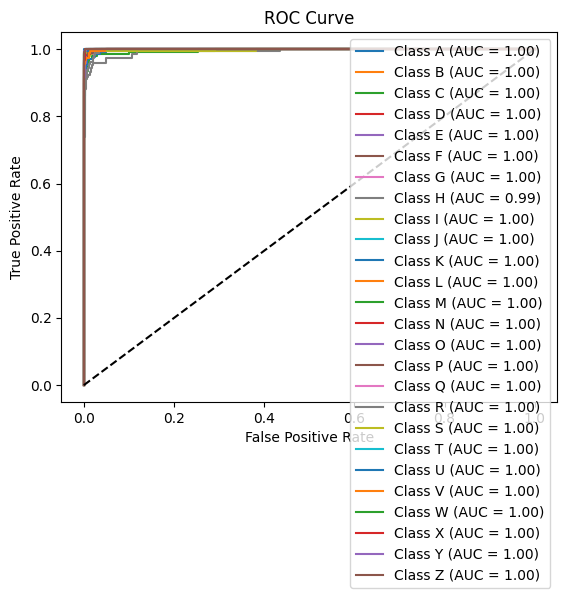

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler, label_binarize
import matplotlib.pyplot as plt


data = pd.read_csv("letter-recognition.csv")

X = data.iloc[:, 1:]
y = data.iloc[:, 0]

classes = sorted(y.unique())
y_bin = label_binarize(y, classes=classes)

X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(X, y, y_bin, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SVC(kernel='rbf', probability=True)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

y_score = model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

Accuracy: 0.95
Confusion Matrix:
 [[148   0   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  1 147   0   3   0   0   0   0   0   0   0   0   0   0   0   0   0   2
    0   0   0   0   0   0   0   0]
 [  0   0 126   0   2   0   2   1   0   0   2   0   0   0   4   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   1   0 153   0   0   0   1   0   0   0   0   0   1   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   0   1   0 135   0   3   0   0   0   0   0   0   0   0   0   1   0
    0   0   0   0   0   0   0   1]
 [  0   1   0   0   1 134   0   0   1   0   0   0   0   0   0   1   0   0
    0   2   0   0   0   0   0   0]
 [  0   0   1   3   0   0 153   0   0   0   0   0   0   0   0   0   0   2
    0   0   0   1   0   0   0   0]
 [  0   3   0   4   0   0   1 118   0   0   4   0   0   1   2   0   0   8
    0   0   1   0   0   1   1   0]
 [  0   0   0   0   0   2   0   0 136   7   0   0   0   0   0   0   0   0
    0   0   0   0   

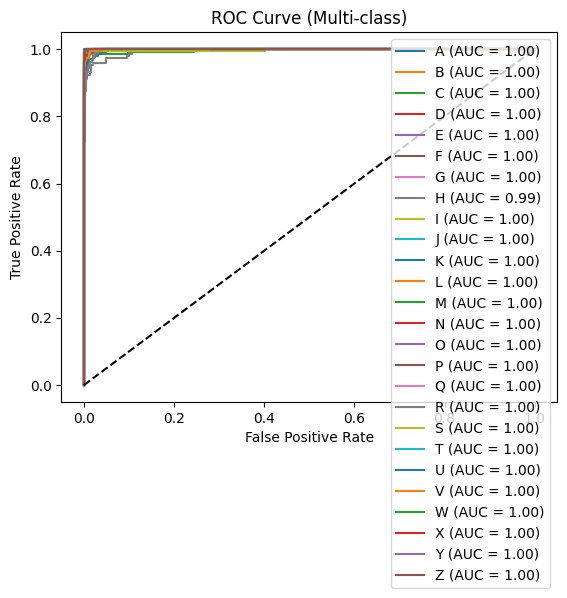

In [ ]:
# With AUC Score

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import StandardScaler, label_binarize
import matplotlib.pyplot as plt
import numpy as np

data = pd.read_csv("letter-recognition.csv")

X = data.iloc[:, 1:]
y = data.iloc[:, 0]

classes = sorted(y.unique())
y_bin = label_binarize(y, classes=classes)

X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(X, y, y_bin, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SVC(kernel='rbf', probability=True)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


y_score = model.predict_proba(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

print("\nAUC for each class:")
for i in range(len(classes)):
    print(f"Class {classes[i]} AUC: {roc_auc[i]:.3f}")

macro_auc = np.mean(list(roc_auc.values()))
print("\nMacro Average AUC:", round(macro_auc, 3))

weighted_auc = roc_auc_score(y_test_bin, y_score, average='weighted', multi_class='ovr')
print("Weighted AUC:", round(weighted_auc, 3))

plt.figure()
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label=f'{classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Multi-class)')
plt.legend()
plt.show()